# WeldSight — EDA

Dataset: the prepared manifest in `data/processed/<name>` (default RIAWELC, re-split by weld specimen).
Sections: provenance · audit of the published split · class balance · effective sample size ·
defect size (mask datasets only) · examples per class.

In [1]:
import hashlib
import json
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data/processed/riawelc_v1"
RAW = ROOT / "data/raw/riawelc"
FIG = ROOT / "notebooks/figures"; FIG.mkdir(exist_ok=True)
df = pd.read_csv(PROC / "manifest.csv", keep_default_na=False)
card = json.loads((PROC / "dataset_card.json").read_text())
CLS = card["class_names"]
df["label"] = "no_defect"
for c in CLS:
    df.loc[df[f"cls_{c}"] == 1, "label"] = c
{k: card[k] for k in ["name", "source", "license", "supervision", "n_records_raw", "n_records",
                      "duplicates_dropped", "n_patches", "patches_per_split", "radiographs_per_split",
                      "data_version"]}

{'name': 'riawelc_v1',
 'source': 'riawelc',
 'license': "No explicit license; README: 'released freely', cite Totino et al. 2022 and Perri et al. 2023",
 'supervision': 'label',
 'n_records_raw': 24407,
 'n_records': 21964,
 'duplicates_dropped': 2443,
 'n_patches': 21964,
 'patches_per_split': {'train': 15560, 'val': 3331, 'test': 3073},
 'radiographs_per_split': {'test': 21, 'train': 64, 'val': 24},
 'data_version': '2c33eedecb1697b9'}

## 1. Audit of the split published with RIAWELC

RIAWELC ships `training/validation/testing` folders. File names encode the source radiograph
(`RRT-26R_Img2_...`), so we can check whether those splits are independent.

In [2]:
pat = re.compile(r"^(?P<spec>.+?)_Img(?P<img>\d+)_A\d+_S\d+_\[\d+\]\[\d+\].*\.png$")
rows = []
if RAW.exists():
    for f in RAW.rglob("*.png"):
        m = pat.match(f.name)
        rows.append({"orig_split": f.parent.parent.name, "folder": f.parent.name, "spec": m["spec"],
                     "radiograph": f"{m['spec']}_Img{m['img']}",
                     "md5": hashlib.md5(f.read_bytes()).hexdigest()})
raw = pd.DataFrame(rows)
if len(raw):
    rs = {s: set(raw.loc[raw.orig_split == s, "radiograph"]) for s in ["training", "validation", "testing"]}
    dup = raw.groupby("md5")["orig_split"].nunique()
    audit = {
        "files": len(raw),
        "radiographs total": raw.radiograph.nunique(),
        "weld specimens total": raw.spec.nunique(),
        "radiographs in testing": len(rs["testing"]),
        "... of which also in training": len(rs["testing"] & rs["training"]),
        "byte-identical files": int((raw.groupby("md5").size() - 1).sum()),
        "... md5 groups spanning >1 split": int((dup > 1).sum()),
    }
    display(pd.Series(audit, name="published RIAWELC split"))
else:
    print("raw RIAWELC not found — skip audit")

files                               24407
radiographs total                     109
weld specimens total                   29
radiographs in testing                108
... of which also in training         108
byte-identical files                 2443
... md5 groups spanning >1 split     2443
Name: published RIAWELC split, dtype: int64

**Conclusion.** The published split is patch-level: almost every radiograph appears in both
training and testing, and thousands of files are exact copies across splits. Accuracies reported on
it measure memorisation of radiographs, not generalisation. We drop duplicates and re-split by
**weld specimen** (all films of a specimen go to one split).

## 2. Class balance after the specimen-level split

split,train,val,test
label,,,
crack,4817,1076,977
lack_of_penetration,2813,535,658
no_defect,4030,868,502
porosity,3900,852,936


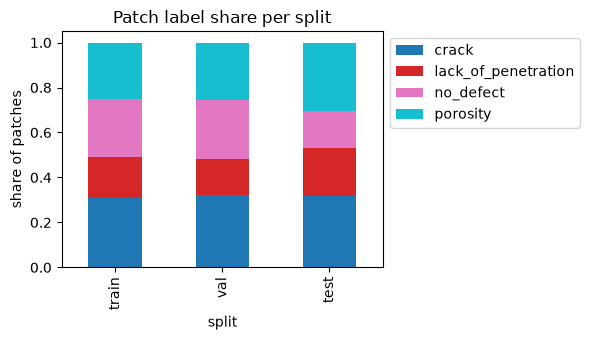

In [3]:
ct = pd.crosstab(df["label"], df["split"])[["train", "val", "test"]]
display(ct)
ax = (ct / ct.sum()).T.plot.bar(stacked=True, figsize=(6, 3.5), colormap="tab10")
ax.set_ylabel("share of patches"); ax.set_title("Patch label share per split"); ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.savefig(FIG / "class_balance.png", dpi=120); plt.show()

## 3. Effective sample size: patches ≠ independent samples

What matters for generalisation is how many *specimens* show each defect class.

,specimens with class,patches,max share from one specimen
label,,,
crack,13,6870,0.23
lack_of_penetration,10,4006,0.26
no_defect,24,5400,0.15
porosity,20,5688,0.20


specimens per split,crack,lack_of_penetration,porosity
split,,,
test,2,3,4
train,9,5,11
val,2,2,5


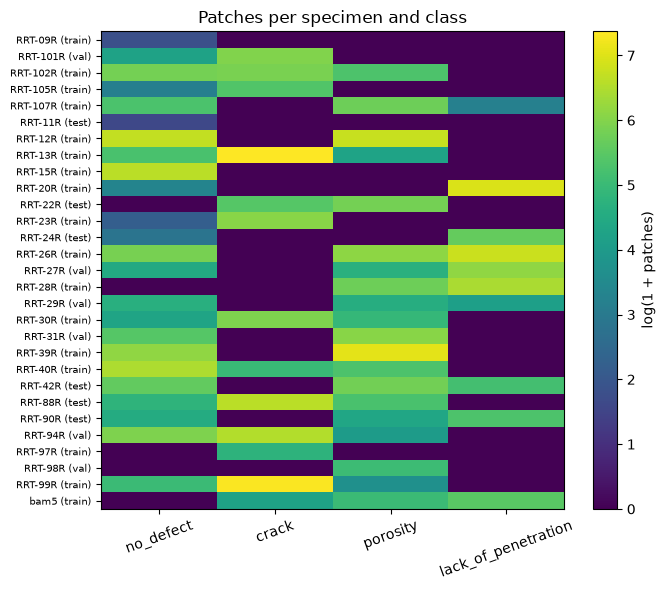

In [4]:
spec = pd.crosstab(df["group_id"], df["label"])
display(pd.DataFrame({
    "specimens with class": (spec > 0).sum(),
    "patches": spec.sum(),
    "max share from one specimen": (spec.max() / spec.sum()).round(2),
}))
per_split = df[df.label != "no_defect"].groupby(["split", "label"])["group_id"].nunique().unstack()
display(per_split.rename_axis(columns="specimens per split"))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(np.log1p(spec[["no_defect"] + CLS].values), aspect="auto", cmap="viridis")
ax.set_yticks(range(len(spec))); ax.set_yticklabels([f"{g} ({df.loc[df.group_id==g,'split'].iat[0]})" for g in spec.index], fontsize=7)
ax.set_xticks(range(len(CLS) + 1)); ax.set_xticklabels(["no_defect"] + CLS, rotation=20)
plt.colorbar(im, label="log(1 + patches)"); ax.set_title("Patches per specimen and class")
plt.tight_layout(); plt.savefig(FIG / "specimen_heatmap.png", dpi=120); plt.show()

**Conclusion.** ~21k patches come from only 29 weld specimens. Lack of penetration occurs in
~10 specimens, so the test set sees it in only 2–3 specimens: per-class recall has wide confidence
intervals (we report cluster-bootstrap CIs over radiographs).

## 4. Defect size

In [5]:
px_cols = [f"px_{c}" for c in CLS if f"px_{c}" in df]
if px_cols:
    areas = []
    for p in df.loc[df.has_mask == 1, "mask"]:
        m = cv2.imread(str(PROC / p), cv2.IMREAD_GRAYSCALE)
        for k, c in enumerate(CLS, 1):
            n, lab, st, _ = cv2.connectedComponentsWithStats((m == k).astype(np.uint8))
            areas += [{"class": c, "area": a, "w": w, "h": h} for (_, _, w, h, a) in st[1:]]
    areas = pd.DataFrame(areas)
    display(areas.groupby("class")["area"].describe())
    areas.boxplot("area", by="class", figsize=(6, 3.5)); plt.yscale("log"); plt.show()
else:
    print("No pixel masks in this dataset (label-only supervision) -> defect size cannot be measured.")

No pixel masks in this dataset (label-only supervision) -> defect size cannot be measured.


For label-only data we show a *proxy*: intensity contrast of the patch (std and the share of
pixels more than 2σ darker than the patch median). It is **not** a defect size measurement.

,std,dark_share,mean
label,,,
crack,24.823999,0.047,155.824997
lack_of_penetration,27.777000,0.045,164.054993
no_defect,7.058000,0.026,150.742996
porosity,26.528999,0.044,147.654007


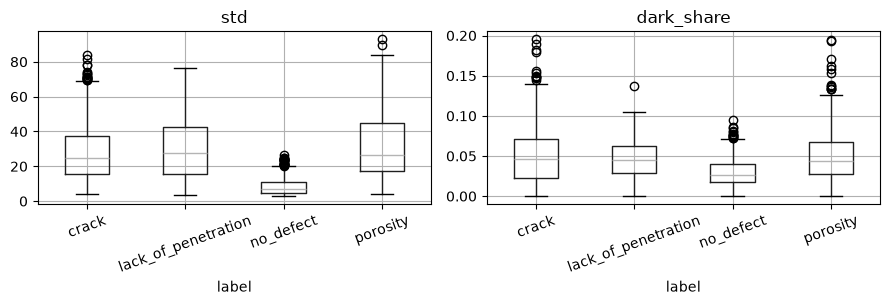

In [6]:
rng = np.random.default_rng(0)
stats = []
for lab, g in df.groupby("label"):
    for p in g.sample(min(400, len(g)), random_state=0)["image"]:
        x = cv2.imread(str(PROC / p), cv2.IMREAD_GRAYSCALE).astype(np.float32)
        s = x.std() + 1e-6
        stats.append({"label": lab, "std": s, "dark_share": float((x < np.median(x) - 2 * s).mean()),
                      "mean": x.mean()})
stats = pd.DataFrame(stats)
display(stats.groupby("label").median().round(3))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
stats.boxplot("std", by="label", ax=ax[0]); stats.boxplot("dark_share", by="label", ax=ax[1])
for a in ax: a.tick_params(axis="x", rotation=20)
plt.suptitle(""); plt.tight_layout(); plt.savefig(FIG / "contrast_proxy.png", dpi=120); plt.show()

**Warning — shortcut.** No-defect patches have a much lower intensity std (~7 vs ~25 grey
levels) than any defect class: they were cropped from flat regions. A trivial std threshold nearly
separates *defect vs no defect*, so high "any-defect" recall on RIAWELC is not evidence of a good
detector. The informative part is discrimination **between** defect classes and recall per class.

In [7]:
from sklearn.metrics import roc_auc_score

print("AUROC of patch std for defect-vs-no-defect:",
      round(roc_auc_score(stats["label"] != "no_defect", stats["std"]), 3))

AUROC of patch std for defect-vs-no-defect: 0.91


## 5. Examples per class (one patch per specimen where possible)

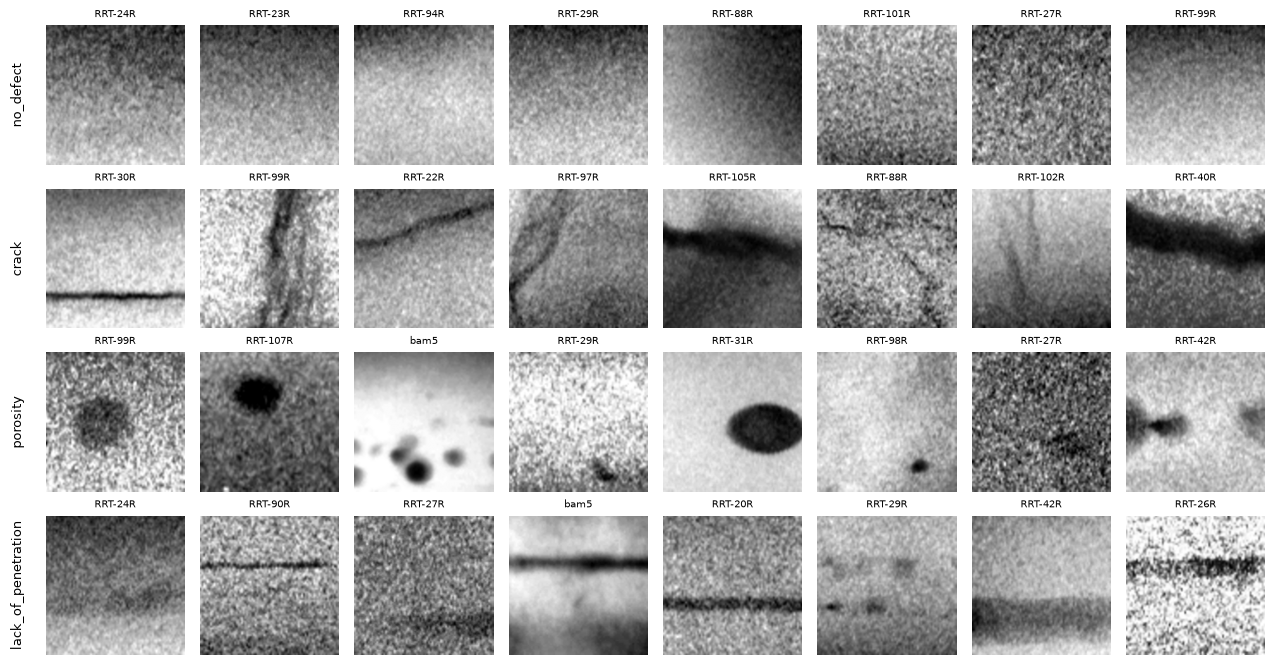

In [8]:
n = 8
fig, axes = plt.subplots(len(CLS) + 1, n, figsize=(n * 1.6, (len(CLS) + 1) * 1.7))
for r, lab in enumerate(["no_defect"] + CLS):
    g = df[df.label == lab].groupby("group_id").sample(1, random_state=0)
    g = g.sample(min(n, len(g)), random_state=0)
    for c in range(n):
        ax = axes[r, c]; ax.axis("off")
        if c < len(g):
            ax.imshow(cv2.imread(str(PROC / g.iloc[c]["image"]), cv2.IMREAD_GRAYSCALE), cmap="gray")
            ax.set_title(g.iloc[c]["group_id"], fontsize=7)
    axes[r, 0].text(-40, 128, lab, rotation=90, va="center", ha="right", fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "examples.png", dpi=110); plt.show()

## Take-aways for modelling
1. Evaluate only on the specimen-level split; never on the published one.
2. Report per-class recall with specimen/radiograph-level CIs — test has 6 specimens.
3. RIAWELC has no masks: segmentation IoU requires SWRD (polygons) or GDXray (binary masks).
4. Brightness/contrast differ strongly between specimens -> per-patch normalisation.
5. No-defect patches are trivially separable by contrast; do not use "defect vs no defect" accuracy
   as the headline metric.